In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
states = ["S1", "S2", "S3", "S4", "S5"]
actions = ["UP", "DOWN", "LEFT", "RIGHT"]

start_state = "S1"
goal_state = "S5"

gamma = 0.9

theta = 1e-6

print("States:", states)
print("Actions:", actions)
print("Start State:", start_state)
print("Goal State:", goal_state)
print("Discount Factor:", gamma)

States: ['S1', 'S2', 'S3', 'S4', 'S5']
Actions: ['UP', 'DOWN', 'LEFT', 'RIGHT']
Start State: S1
Goal State: S5
Discount Factor: 0.9


**TASK 1 : FORMULATING THE GRID ENVIRONMENT**

In [3]:
positions = {
    "S1": (0, 0),
    "S2": (0, 1),
    "S3": (0, 2),
    "S4": (1, 0),
    "S5": (1, 1)
}
moves = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1)
}

In [24]:
arrows = {
    "UP": "↑",
    "DOWN": "↓",
    "LEFT": "←",
    "RIGHT": "→"
}

print("┌──────┬──────┬──────┐")
print(f"│  {arrows[optimal_policy['S1']]}   │  {arrows[optimal_policy['S2']]}   │  {arrows[optimal_policy['S3']]}   │")
print("├──────┼──────┼──────┤")
print(f"│  {arrows[optimal_policy['S4']]}   │ S5 ★ │  ■   │")
print("└──────┴──────┴──────┘")

┌──────┬──────┬──────┐
│  ↓   │  ↓   │  ←   │
├──────┼──────┼──────┤
│  →   │ S5 ★ │  ■   │
└──────┴──────┴──────┘


In [5]:
def step(state, action):

    if state == goal_state:
        return goal_state, 0

    row, col = positions[state]

    dr, dc = moves[action]

    new_position = (row + dr, col + dc)

    next_state = None

    for s, position in positions.items():
        if position == new_position:
            next_state = s
            break

    if next_state is None:
        return state, -1
    return next_state, -1

In [6]:
print("S1 + RIGHT =", step("S1", "RIGHT"))
print("S2 + DOWN  =", step("S2", "DOWN"))
print("S3 + DOWN  =", step("S3", "DOWN"))

S1 + RIGHT = ('S2', -1)
S2 + DOWN  = ('S5', -1)
S3 + DOWN  = ('S3', -1)


In [7]:
state_to_index = {
    state: i for i, state in enumerate(states)
}

action_to_index = {
    action: i for i, action in enumerate(actions)
}

P = np.zeros(
    (len(states), len(actions), len(states))
)

R = np.zeros(
    (len(states), len(actions))
)

for state in states:

    state_index = state_to_index[state]

    for action in actions:

        action_index = action_to_index[action]

        next_state, reward = step(state, action)

        next_state_index = state_to_index[next_state]

        P[state_index, action_index, next_state_index] = 1.0

        R[state_index, action_index] = reward


goal_index = state_to_index[goal_state]

P[goal_index, :, :] = 0
P[goal_index, :, goal_index] = 1

R[goal_index, :] = 0

print("Transition matrix shape:", P.shape)
print("Reward matrix shape:", R.shape)

Transition matrix shape: (5, 4, 5)
Reward matrix shape: (5, 4)


In [8]:
rows = []

for state in states:

    for action in actions:

        next_state, reward = step(state, action)

        rows.append([
            state,
            action,
            next_state,
            reward
        ])

transition_table = pd.DataFrame(
    rows,
    columns=[
        "State",
        "Action",
        "Next State",
        "Reward"
    ]
)

transition_table

,State,Action,Next State,Reward
0,S1,UP,S1,-1
1,S1,DOWN,S4,-1
2,S1,LEFT,S1,-1
3,S1,RIGHT,S2,-1
4,S2,UP,S2,-1
5,S2,DOWN,S5,-1
6,S2,LEFT,S1,-1
7,S2,RIGHT,S3,-1
8,S3,UP,S3,-1
9,S3,DOWN,S3,-1


**TASK 2 : POLICY EVALUATION**

In [9]:
evaluated_policy = {
    "S1": "RIGHT",
    "S2": "DOWN",
    "S3": "LEFT",
    "S4": "RIGHT"
}

print("Evaluated Policy:")

for state, action in evaluated_policy.items():
    print(state, "->", action)

Evaluated Policy:
S1 -> RIGHT
S2 -> DOWN
S3 -> LEFT
S4 -> RIGHT


In [10]:
def policy_evaluation(policy, iterations=5):

    V = {
        state: 0.0
        for state in states
    }

    history = []

    for iteration in range(1, iterations + 1):

        new_V = V.copy()

        for state in states:

            if state == goal_state:
                new_V[state] = 0.0
                continue

            action = policy[state]

            next_state, reward = step(
                state,
                action
            )

            new_V[state] = (
                reward
                + gamma * V[next_state]
            )

        delta = max(
            abs(
                new_V[state] - V[state]
            )
            for state in states
        )

        history.append({
            "Iteration": iteration,
            "S1": new_V["S1"],
            "S2": new_V["S2"],
            "S3": new_V["S3"],
            "S4": new_V["S4"],
            "S5": new_V["S5"],
            "Maximum Change (Δ)": delta
        })

        V = new_V

    return pd.DataFrame(history), V

In [11]:
policy_eval_table, evaluated_values = policy_evaluation(
    evaluated_policy,
    iterations=5
)

policy_eval_table.round(4)

,Iteration,S1,S2,S3,S4,S5,Maximum Change (Δ)
0,1,-1.0,-1.0,-1.0,-1.0,0.0,1.0
1,2,-1.9,-1.0,-1.9,-1.0,0.0,0.9
2,3,-1.9,-1.0,-1.9,-1.0,0.0,0.0
3,4,-1.9,-1.0,-1.9,-1.0,0.0,0.0
4,5,-1.9,-1.0,-1.9,-1.0,0.0,0.0


In [12]:
task2_table = policy_eval_table[
    ["Iteration", "Maximum Change (Δ)"]
].copy()

task2_table["Convergence Status"] = np.where(
    task2_table["Maximum Change (Δ)"] < theta,
    "Converged",
    "Not converged"
)

task2_table.round(4)

,Iteration,Maximum Change (Δ),Convergence Status
0,1,1.0,Not converged
1,2,0.9,Not converged
2,3,0.0,Converged
3,4,0.0,Converged
4,5,0.0,Converged


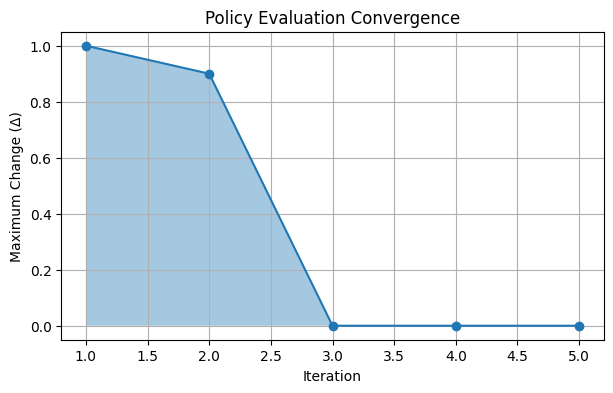

In [15]:
plt.figure(figsize=(7, 4))

plt.fill_between(
    policy_eval_table["Iteration"],
    policy_eval_table["Maximum Change (Δ)"],
    alpha=0.4
)

plt.plot(
    policy_eval_table["Iteration"],
    policy_eval_table["Maximum Change (Δ)"],
    marker="o"
)

plt.xlabel("Iteration")
plt.ylabel("Maximum Change (Δ)")
plt.title("Policy Evaluation Convergence")
plt.grid(True)

plt.show()

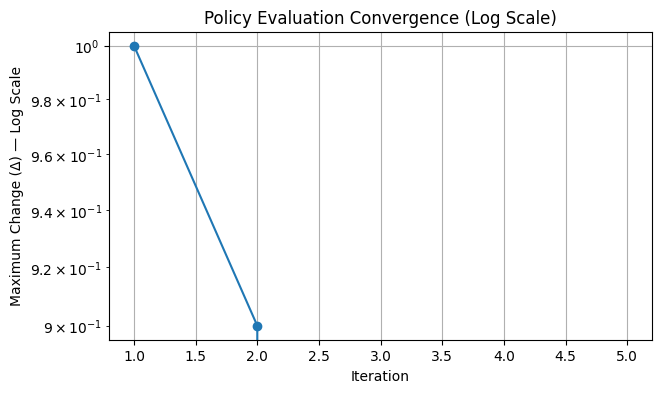

In [16]:
plt.figure(figsize=(7, 4))

plt.semilogy(
    policy_eval_table["Iteration"],
    policy_eval_table["Maximum Change (Δ)"],
    marker="o"
)

plt.xlabel("Iteration")
plt.ylabel("Maximum Change (Δ) — Log Scale")
plt.title("Policy Evaluation Convergence (Log Scale)")
plt.grid(True)

plt.show()

**Task 3: Value Iteration and Optimal Policy Generation**

In [17]:
def value_iteration(theta=1e-6):

    V = {
        state: 0.0
        for state in states
    }

    history = []

    while True:

        new_V = V.copy()

        for state in states:

            if state == goal_state:
                new_V[state] = 0.0
                continue

            action_values = []

            for action in actions:

                next_state, reward = step(
                    state,
                    action
                )

                value = (
                    reward
                    + gamma * V[next_state]
                )

                action_values.append(value)

            new_V[state] = max(
                action_values
            )

        delta = max(
            abs(
                new_V[state] - V[state]
            )
            for state in states
        )

        history.append({
            "Iteration": len(history) + 1,
            "S1": new_V["S1"],
            "S2": new_V["S2"],
            "S3": new_V["S3"],
            "S4": new_V["S4"],
            "S5": new_V["S5"],
            "Maximum Change (Δ)": delta
        })

        V = new_V

        if delta < theta:
            break

    return V, pd.DataFrame(history)

In [18]:
optimal_values, value_iteration_history = value_iteration()

print("Optimal State Values:")

for state in states:
    print(
        state,
        "=",
        round(optimal_values[state], 4)
    )

Optimal State Values:
S1 = -1.9
S2 = -1.0
S3 = -1.9
S4 = -1.0
S5 = 0.0


In [19]:
value_iteration_history.round(4)

,Iteration,S1,S2,S3,S4,S5,Maximum Change (Δ)
0,1,-1.0,-1.0,-1.0,-1.0,0.0,1.0
1,2,-1.9,-1.0,-1.9,-1.0,0.0,0.9
2,3,-1.9,-1.0,-1.9,-1.0,0.0,0.0


In [20]:
def get_optimal_policy(V):

    optimal_policy = {}

    for state in states:

        if state == goal_state:
            continue

        best_action = None
        best_value = -float("inf")

        for action in actions:

            next_state, reward = step(
                state,
                action
            )

            q_value = (
                reward
                + gamma * V[next_state]
            )

            if q_value > best_value:

                best_value = q_value
                best_action = action

        optimal_policy[state] = best_action

    return optimal_policy


optimal_policy = get_optimal_policy(
    optimal_values
)

for state, action in optimal_policy.items():
    print(state, "->", action)

S1 -> DOWN
S2 -> DOWN
S3 -> LEFT
S4 -> RIGHT


In [21]:
task3_table = pd.DataFrame({
    "State": states,

    "Optimal Action": [
        optimal_policy[state]
        if state != goal_state
        else "Terminal"
        for state in states
    ],

    "State Value": [
        optimal_values[state]
        for state in states
    ]
})

task3_table.round(4)

,State,Optimal Action,State Value
0,S1,DOWN,-1.9
1,S2,DOWN,-1.0
2,S3,LEFT,-1.9
3,S4,RIGHT,-1.0
4,S5,Terminal,0.0


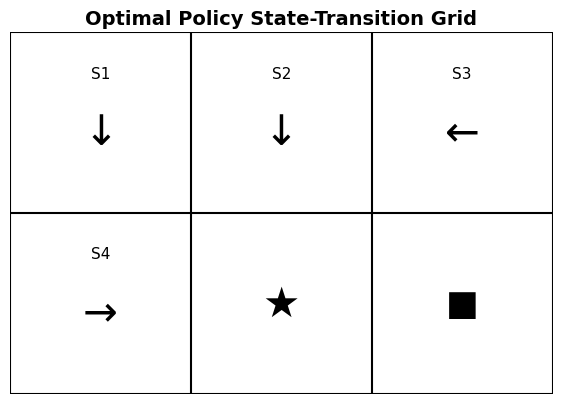

In [23]:
import matplotlib.pyplot as plt

arrows = {
    "UP": "↑",
    "DOWN": "↓",
    "LEFT": "←",
    "RIGHT": "→"
}

fig, ax = plt.subplots(figsize=(7, 5))

# Grid
for x in range(4):
    ax.plot([x, x], [0, 2], color="black", linewidth=1.5)
for y in range(3):
    ax.plot([0, 3], [y, y], color="black", linewidth=1.5)

# States
states = {
    "S1": (0.5, 1.5),
    "S2": (1.5, 1.5),
    "S3": (2.5, 1.5),
    "S4": (0.5, 0.5)
}

# Draw state labels and policies
for state, (x, y) in states.items():
    ax.text(x, y + 0.25, state,
            ha="center", fontsize=11)

    ax.text(
        x, y - 0.05,
        arrows[optimal_policy[state]],
        ha="center",
        va="center",
        fontsize=30
    )

# Goal and blocked state
ax.text(1.5, 0.5, "★",
        ha="center", va="center", fontsize=30)

ax.text(2.5, 0.5, "■",
        ha="center", va="center", fontsize=25)

# Formatting
ax.set_xlim(0, 3)
ax.set_ylim(0, 2)
ax.set_aspect("equal")
ax.axis("off")

plt.title("Optimal Policy State-Transition Grid",
          fontsize=14, fontweight="bold")

plt.show()

In [25]:
def run_episode(policy_function, max_steps=50):

    state = start_state

    path = [state]

    total_reward = 0

    for _ in range(max_steps):

        if state == goal_state:
            break

        action = policy_function(state)

        next_state, reward = step(
            state,
            action
        )

        path.append(next_state)

        total_reward += reward

        state = next_state

    return {
        "Path": path,
        "Path Length": len(path) - 1,
        "Total Reward": total_reward,
        "Goal Reached": state == goal_state
    }

In [26]:
def random_policy(state):

    if state == goal_state:
        return None

    return random.choice(actions)


def evaluated_policy_function(state):

    if state == goal_state:
        return None

    return evaluated_policy[state]


def optimal_policy_function(state):

    if state == goal_state:
        return None

    return optimal_policy[state]

In [27]:
random.seed(10)

random_result = run_episode(
    random_policy
)

print("Random Policy")
print("--------------------")

print(
    "Path:",
    " -> ".join(random_result["Path"])
)

print(
    "Steps:",
    random_result["Path Length"]
)

print(
    "Total Reward:",
    random_result["Total Reward"]
)

print(
    "Goal Reached:",
    random_result["Goal Reached"]
)

Random Policy
--------------------
Path: S1 -> S1 -> S2 -> S3 -> S3 -> S3 -> S3 -> S3 -> S2 -> S5
Steps: 9
Total Reward: -9
Goal Reached: True


In [28]:
evaluated_result = run_episode(
    evaluated_policy_function
)

print("Evaluated Policy")
print("--------------------")

print(
    "Path:",
    " -> ".join(evaluated_result["Path"])
)

print(
    "Steps:",
    evaluated_result["Path Length"]
)

print(
    "Total Reward:",
    evaluated_result["Total Reward"]
)

print(
    "Goal Reached:",
    evaluated_result["Goal Reached"]
)

Evaluated Policy
--------------------
Path: S1 -> S2 -> S5
Steps: 2
Total Reward: -2
Goal Reached: True


In [29]:
optimal_result = run_episode(
    optimal_policy_function
)

print("Optimal Policy")
print("--------------------")

print(
    "Path:",
    " -> ".join(optimal_result["Path"])
)

print(
    "Steps:",
    optimal_result["Path Length"]
)

print(
    "Total Reward:",
    optimal_result["Total Reward"]
)

print(
    "Goal Reached:",
    optimal_result["Goal Reached"]
)

Optimal Policy
--------------------
Path: S1 -> S4 -> S5
Steps: 2
Total Reward: -2
Goal Reached: True


In [30]:
comparison_table = pd.DataFrame([
    [
        "Random Policy",
        random_result["Path Length"],
        random_result["Total Reward"],
        random_result["Goal Reached"]
    ],

    [
        "Evaluated Policy",
        evaluated_result["Path Length"],
        evaluated_result["Total Reward"],
        evaluated_result["Goal Reached"]
    ],

    [
        "Optimal Policy",
        optimal_result["Path Length"],
        optimal_result["Total Reward"],
        optimal_result["Goal Reached"]
    ]

], columns=[
    "Policy Type",
    "Path Length",
    "Total Reward",
    "Goal Reached"
])

comparison_table

,Policy Type,Path Length,Total Reward,Goal Reached
0,Random Policy,9,-9,True
1,Evaluated Policy,2,-2,True
2,Optimal Policy,2,-2,True


In [31]:
print("PATH COMPARISON")
print("=" * 60)

print(
    "Random Policy:",
    " -> ".join(random_result["Path"])
)

print(
    "Evaluated Policy:",
    " -> ".join(evaluated_result["Path"])
)

print(
    "Optimal Policy:",
    " -> ".join(optimal_result["Path"])
)

PATH COMPARISON
Random Policy: S1 -> S1 -> S2 -> S3 -> S3 -> S3 -> S3 -> S3 -> S2 -> S5
Evaluated Policy: S1 -> S2 -> S5
Optimal Policy: S1 -> S4 -> S5
